                                                   TMDB Movie Dataset Builder



# Web Scraping

## 1 & 2. Setup and API Authentication

In [ ]:
# Cell 1 — Install / import dependencies
# tqdm and requests ship in Colab already; this just guarantees current versions.
!pip install -q requests pandas tqdm pyarrow

import os
import json
import time
import random
import logging
from datetime import datetime
from pathlib import Path

import requests
import pandas as pd
from tqdm.auto import tqdm
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("tmdb_pipeline")

### Get TMDB API Read Access Token

In [ ]:
try:
    from google.colab import userdata
    TMDB_API_TOKEN = userdata.get("TMDB_API_TOKEN")
except Exception:
    # Not running in Colab, or secret not set via the UI -> fall back to an env var.
    # e.g. in a terminal: export TMDB_API_TOKEN="your_token_here"
    TMDB_API_TOKEN = os.environ.get("TMDB_API_TOKEN")

if not TMDB_API_TOKEN:
    raise RuntimeError(
        "TMDB_API_TOKEN not found. Add it via the Colab Secrets panel (key icon, left "
        "sidebar) with the exact name 'TMDB_API_TOKEN', or set it as an environment "
        "variable if running outside Colab."
    )

TMDB_BASE_URL = "https://api.themoviedb.org/3"
HEADERS = {
    "Authorization": f"Bearer {TMDB_API_TOKEN}",
    "accept": "application/json",
}
logger.info("TMDB token loaded (length=%d, not printed).", len(TMDB_API_TOKEN))

## 3. Test API request (verify auth works before collecting anything)

In [ ]:
# Cell 3 — Minimal smoke test: fetch one well-known movie (Fight Club, id=550)
test_resp = requests.get(f"{TMDB_BASE_URL}/movie/550", headers=HEADERS, timeout=10)

print("Status code:", test_resp.status_code)
if test_resp.status_code == 200:
    data = test_resp.json()
    print("Auth OK. Sample title:", data.get("title"), "| release_date:", data.get("release_date"))
else:
    print("Auth FAILED. Response body:", test_resp.text[:500])
    raise RuntimeError("Fix authentication before proceeding — check your TMDB_API_TOKEN secret.")

Status code: 200
Auth OK. Sample title: Fight Club | release_date: 1999-10-15


## 12 & 13. Rate-limit handling and retry mechanism (shared helper)
Because we sent more requests show you should do Retry mechanism


In [ ]:
# Cell 4 — Resilient session + request helper used by every downstream call

session = requests.Session()
retry_strategy = Retry(
    total=5,
    backoff_factor=1.5,           # 1.5s, 3s, 6s, 12s, 24s between retries
    status_forcelist=[500, 502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retry_strategy))

REQUEST_DELAY_SECONDS = 0.15   # self-throttle: ~6-7 req/s, well under TMDB's informal ceiling

def tmdb_get(path, params=None, max_429_retries=5):
    """GET a TMDB endpoint with rate-limit (429) and timeout handling.

    Returns parsed JSON dict on success, or None if the request ultimately failed
    (caller decides how to handle a None — e.g. skip and log, don't crash the run).
    """
    url = f"{TMDB_BASE_URL}{path}"
    attempt = 0
    while attempt <= max_429_retries:
        try:
            resp = session.get(url, headers=HEADERS, params=params, timeout=15)
        except requests.exceptions.Timeout:
            logger.warning("Timeout on %s (attempt %d) — retrying.", path, attempt + 1)
            time.sleep(2 ** attempt)
            attempt += 1
            continue
        except requests.exceptions.RequestException as e:
            logger.error("Request error on %s: %s", path, e)
            return None

        if resp.status_code == 200:
            time.sleep(REQUEST_DELAY_SECONDS)
            try:
                return resp.json()
            except ValueError:
                logger.error("Malformed JSON from %s — skipping.", path)
                return None

        if resp.status_code == 429:
            retry_after = resp.headers.get("Retry-After")
            wait = float(retry_after) if retry_after else (2 ** attempt) + random.random()
            logger.warning("429 rate-limited on %s — waiting %.1fs.", path, wait)
            time.sleep(wait)
            attempt += 1
            continue

        if resp.status_code == 404:
            logger.info("404 Not Found: %s (likely deleted/private movie) — skipping.", path)
            return None

        logger.error("HTTP %d on %s: %s", resp.status_code, path, resp.text[:200])
        return None

    logger.error("Exceeded retries for %s — giving up on this request.", path)
    return None

## 14 & 15. Incremental saving, checkpoints, and resuming after interruption


In [ ]:
# Cell 5 — Mount Drive and define the project's file layout
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/tmdb_dataset_project")
RAW_DIR = PROJECT_DIR / "raw_json"          # one JSON file per movie (append_to_response payload)
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
TABLES_DIR = PROJECT_DIR / "tables"          # final relational CSVs
EXPORT_DIR = PROJECT_DIR / "exports"         # final combined exports (csv/json/parquet)

for d in [PROJECT_DIR, RAW_DIR, CHECKPOINT_DIR, TABLES_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MOVIE_IDS_FILE = CHECKPOINT_DIR / "movie_ids.json"
COLLECTED_IDS_FILE = CHECKPOINT_DIR / "collected_ids.json"
CHECKPOINT_EVERY = 100   # save progress every 100 movies

def load_json_set(path):
    if path.exists():
        with open(path) as f:
            return set(json.load(f))
    return set()

def save_json_set(data, path):
    with open(path, "w") as f:
        json.dump(sorted(data), f)

logger.info("Project directory: %s", PROJECT_DIR)

Mounted at /content/drive


## 4 & 5. Discovering movie IDs, and pagination strategy



In [ ]:
# Cell 6 — Discovery configuration (EDIT THESE VALUES YOURSELF)
MIN_VOTE_COUNT = 50          # <-- raise for a smaller/cleaner set, lower for a bigger one
YEAR_RANGES = [
    (1990, 1999),
    (2000, 2009),
    (2010, 2015),
    (2016, 2019),
    (2020, 2023),
    (2024, 2026),
]  # <-- edit freely; narrower ranges = safer margin under the 10,000-result cap per slice

def discover_ids_for_range(start_year, end_year, min_vote_count):
    """Paginate discover/movie for one year range, stopping at the 500-page ceiling."""
    ids = set()
    params = {
        "sort_by": "vote_count.desc",
        "include_adult": "false",
        "include_video": "false",
        "vote_count.gte": min_vote_count,
        "primary_release_date.gte": f"{start_year}-01-01",
        "primary_release_date.lte": f"{end_year}-12-31",
        "page": 1,
    }

    first = tmdb_get("/discover/movie", params=params)
    if not first:
        logger.error("Discovery failed for range %d-%d", start_year, end_year)
        return ids

    total_pages = min(first.get("total_pages", 1), 500)  # hard API ceiling
    logger.info(
        "Range %d-%d: %d total_results across %d pages (capped at 500).",
        start_year, end_year, first.get("total_results", 0), total_pages,
    )
    ids.update(m["id"] for m in first.get("results", []))

    for page in tqdm(range(2, total_pages + 1), desc=f"Discover {start_year}-{end_year}"):
        params["page"] = page
        result = tmdb_get("/discover/movie", params=params)
        if result:
            ids.update(m["id"] for m in result.get("results", []))
    return ids

# Collected Movie ID

In [ ]:
# Cell 7 — Run discovery across all year ranges (resumable: skips if movie_ids.json exists)
if MOVIE_IDS_FILE.exists():
    all_movie_ids = load_json_set(MOVIE_IDS_FILE)
    logger.info("Loaded %d previously discovered movie IDs — skipping discovery.", len(all_movie_ids))
else:
    all_movie_ids = set()
    for start, end in YEAR_RANGES:
        all_movie_ids |= discover_ids_for_range(start, end, MIN_VOTE_COUNT)
        save_json_set(all_movie_ids, MOVIE_IDS_FILE)   # checkpoint after every year range
    logger.info("Discovery complete: %d unique movie IDs.", len(all_movie_ids))

print(f"Total unique movie IDs to collect: {len(all_movie_ids)}")

Discover 1990-1999:   0%|          | 0/170 [00:00<?, ?it/s]

Discover 2000-2009:   0%|          | 0/320 [00:00<?, ?it/s]

Discover 2010-2015:   0%|          | 0/323 [00:00<?, ?it/s]

Discover 2016-2019:   0%|          | 0/280 [00:00<?, ?it/s]

Discover 2020-2023:   0%|          | 0/225 [00:00<?, ?it/s]

Discover 2024-2026:   0%|          | 0/100 [00:00<?, ?it/s]

Total unique movie IDs to collect: 28433


## 6, 7 & 8. Collecting movie details, credits/cast/directors, and genres/keywords


In [ ]:
# Cell 8 — Main collection loop: details + credits + keywords, checkpointed & resumable
collected_ids = load_json_set(COLLECTED_IDS_FILE)
remaining_ids = [mid for mid in sorted(all_movie_ids) if mid not in collected_ids]

logger.info(
    "%d movies already collected, %d remaining.", len(collected_ids), len(remaining_ids)
)

since_last_checkpoint = 0

for movie_id in tqdm(remaining_ids, desc="Collecting movie details"):
    data = tmdb_get(f"/movie/{movie_id}", params={"append_to_response": "credits,keywords"})

    if data is None:
        # Logged already inside tmdb_get; mark as attempted so we don't loop on a
        # permanently-broken ID forever, but tag it so it's easy to filter out later.
        collected_ids.add(movie_id)
        continue

    # Save the raw payload once — this is our source of truth for the parsing step belouw,
    # and means a schema change later never requires re-calling the API.
    with open(RAW_DIR / f"{movie_id}.json", "w") as f:
        json.dump(data, f)

    collected_ids.add(movie_id)
    since_last_checkpoint += 1

    if since_last_checkpoint >= CHECKPOINT_EVERY:
        save_json_set(collected_ids, COLLECTED_IDS_FILE)
        logger.info("Checkpoint: %d / %d movies collected.", len(collected_ids), len(all_movie_ids))
        since_last_checkpoint = 0

# Final checkpoint after the loop finishes
save_json_set(collected_ids, COLLECTED_IDS_FILE)
logger.info("Collection complete: %d movies collected total.", len(collected_ids))

## 9, 10 & 11. Parsing raw JSON into relational tables, cleaning, duplicates, missing values


In [ ]:
# Cell 9 — Parse all raw JSON files into relational rows (in-memory), then build DataFrames
raw_files = list(RAW_DIR.glob("*.json"))
logger.info("Parsing %d raw movie JSON files.", len(raw_files))

movies_rows, genres_rows, movie_genres_rows = [], [], []
people_rows, movie_cast_rows, movie_crew_rows = [], [], []
companies_rows, movie_companies_rows = [], []
countries_rows, movie_countries_rows = [], []
keywords_rows, movie_keywords_rows = [], []

seen_people, seen_genres, seen_companies, seen_countries, seen_keywords = set(), set(), set(), set(), set()
malformed_count = 0

for fp in tqdm(raw_files, desc="Parsing raw JSON"):
    try:
        with open(fp) as f:
            m = json.load(f)
    except (json.JSONDecodeError, OSError):
        malformed_count += 1
        continue

    mid = m.get("id")
    if mid is None:
        malformed_count += 1
        continue

    movies_rows.append({
        "id": mid,
        "title": m.get("title"),
        "original_title": m.get("original_title"),
        "original_language": m.get("original_language"),
        "overview": m.get("overview") or None,
        "release_date": pd.to_datetime(m.get("release_date"), errors="coerce"),
        "popularity": m.get("popularity"),
        "vote_average": m.get("vote_average"),
        "vote_count": m.get("vote_count"),
        "adult": m.get("adult"),
        "video": m.get("video"),
        "poster_path": m.get("poster_path"),
        "backdrop_path": m.get("backdrop_path"),
        "runtime": m.get("runtime") or None,          # 0 -> missing, not zero
        "budget": m.get("budget") or None,             # 0 -> missing, not zero
        "revenue": m.get("revenue") or None,           # 0 -> missing, not zero
        "status": m.get("status"),
        "tagline": m.get("tagline") or None,
    })

    for g in m.get("genres", []):
        if g["id"] not in seen_genres:
            genres_rows.append({"genre_id": g["id"], "name": g["name"]})
            seen_genres.add(g["id"])
        movie_genres_rows.append({"movie_id": mid, "genre_id": g["id"]})

    for kw in (m.get("keywords") or {}).get("keywords", []):
        if kw["id"] not in seen_keywords:
            keywords_rows.append({"keyword_id": kw["id"], "name": kw["name"]})
            seen_keywords.add(kw["id"])
        movie_keywords_rows.append({"movie_id": mid, "keyword_id": kw["id"]})

    for c in m.get("production_companies", []):
        if c["id"] not in seen_companies:
            companies_rows.append({
                "company_id": c["id"], "name": c["name"],
                "origin_country": c.get("origin_country") or None,
            })
            seen_companies.add(c["id"])
        movie_companies_rows.append({"movie_id": mid, "company_id": c["id"]})

    for co in m.get("production_countries", []):
        code_ = co.get("iso_3166_1")
        if code_ and code_ not in seen_countries:
            countries_rows.append({"country_code": code_, "name": co.get("name")})
            seen_countries.add(code_)
        if code_:
            movie_countries_rows.append({"movie_id": mid, "country_code": code_})

    credits = m.get("credits", {})
    for cast in credits.get("cast", []):
        pid = cast["id"]
        if pid not in seen_people:
            people_rows.append({"person_id": pid, "name": cast.get("name"),
                                 "gender": cast.get("gender")})
            seen_people.add(pid)
        movie_cast_rows.append({
            "movie_id": mid, "person_id": pid,
            "character": cast.get("character"), "cast_order": cast.get("order"),
        })

    for crew in credits.get("crew", []):
        pid = crew["id"]
        if pid not in seen_people:
            people_rows.append({"person_id": pid, "name": crew.get("name"),
                                 "gender": crew.get("gender")})
            seen_people.add(pid)
        movie_crew_rows.append({
            "movie_id": mid, "person_id": pid,
            "job": crew.get("job"), "department": crew.get("department"),
        })

if malformed_count:
    logger.warning("Skipped %d malformed/unreadable raw JSON files.", malformed_count)

movies_df = pd.DataFrame(movies_rows).drop_duplicates(subset="id")
genres_df = pd.DataFrame(genres_rows).drop_duplicates(subset="genre_id")
movie_genres_df = pd.DataFrame(movie_genres_rows).drop_duplicates()
people_df = pd.DataFrame(people_rows).drop_duplicates(subset="person_id")
movie_cast_df = pd.DataFrame(movie_cast_rows).drop_duplicates(subset=["movie_id", "person_id", "character"])
movie_crew_df = pd.DataFrame(movie_crew_rows).drop_duplicates(subset=["movie_id", "person_id", "job"])
companies_df = pd.DataFrame(companies_rows).drop_duplicates(subset="company_id")
movie_companies_df = pd.DataFrame(movie_companies_rows).drop_duplicates()
countries_df = pd.DataFrame(countries_rows).drop_duplicates(subset="country_code")
movie_countries_df = pd.DataFrame(movie_countries_rows).drop_duplicates()
keywords_df = pd.DataFrame(keywords_rows).drop_duplicates(subset="keyword_id")
movie_keywords_df = pd.DataFrame(movie_keywords_rows).drop_duplicates()

print(f"movies: {len(movies_df)} rows | genres: {len(genres_df)} | people: {len(people_df)}")
print(f"movie_cast: {len(movie_cast_df)} | movie_crew: {len(movie_crew_df)} | keywords: {len(keywords_df)}")

Parsing raw JSON:   0%|          | 0/28433 [00:00<?, ?it/s]

movies: 28433 rows | genres: 19 | people: 735437
movie_cast: 787733 | movie_crew: 1385346 | keywords: 24563


## 16. Data validation

In [ ]:
# Cell 10 — Sanity checks before export: catch structural problems early
issues = []

if movies_df["id"].duplicated().any():
    issues.append("Duplicate movie IDs found in movies_df after drop_duplicates (bug).")

orphan_genre_links = ~movie_genres_df["genre_id"].isin(genres_df["genre_id"])
if orphan_genre_links.any():
    issues.append(f"{orphan_genre_links.sum()} movie_genres rows reference an unknown genre_id.")

orphan_cast_links = ~movie_cast_df["person_id"].isin(people_df["person_id"])
if orphan_cast_links.any():
    issues.append(f"{orphan_cast_links.sum()} movie_cast rows reference an unknown person_id.")

missing_titles = movies_df["title"].isna().sum()
if missing_titles:
    issues.append(f"{missing_titles} movies have no title.")

pct_missing_budget = movies_df["budget"].isna().mean() * 100
pct_missing_runtime = movies_df["runtime"].isna().mean() * 100

print(f"Rows: {len(movies_df)} movies")
print(f"Missing budget: {pct_missing_budget:.1f}% | Missing runtime: {pct_missing_runtime:.1f}%")
print(f"Date range: {movies_df['release_date'].min()} to {movies_df['release_date'].max()}")

if issues:
    print("\nVALIDATION ISSUES:")
    for i in issues:
        print(" -", i)
else:
    print("\nNo structural validation issues found.")

Rows: 28433 movies
Missing budget: 62.8% | Missing runtime: 0.2%
Date range: 1990-01-01 00:00:00 to 2026-09-23 00:00:00

No structural validation issues found.


## 17. Exporting CSV / JSON / Parquet

In [ ]:
# Cell 11 — Write every table to CSV (source of truth) and a Parquet copy of `movies`
tables = {
    "movies": movies_df, "genres": genres_df, "movie_genres": movie_genres_df,
    "people": people_df, "movie_cast": movie_cast_df, "movie_crew": movie_crew_df,
    "production_companies": companies_df, "movie_production_companies": movie_companies_df,
    "countries": countries_df, "movie_countries": movie_countries_df,
    "keywords": keywords_df, "movie_keywords": movie_keywords_df,
}

for name, df in tables.items():
    df.to_csv(TABLES_DIR / f"{name}.csv", index=False)

# Parquet preserves dtypes (e.g. real datetimes) better than CSV — useful for the movies table
movies_df.to_parquet(EXPORT_DIR / "movies.parquet", index=False)

# One JSON export of movies for tooling that prefers JSON over CSV
movies_df.to_json(EXPORT_DIR / "movies.json", orient="records", date_format="iso")

logger.info("Exported %d tables to %s", len(tables), TABLES_DIR)
print("Files written to:", TABLES_DIR)

Files written to: /content/drive/MyDrive/tmdb_dataset_project/tables


## 18. Loading the final dataset with Pandas

In [ ]:
# Cell 12 — Reload from disk and demonstrate reconstructing a "wide" analysis view
movies = pd.read_csv(TABLES_DIR / "movies.csv", parse_dates=["release_date"])
genres = pd.read_csv(TABLES_DIR / "genres.csv")
movie_genres = pd.read_csv(TABLES_DIR / "movie_genres.csv")

# Example: build one comma-separated genre-name column per movie, on demand
genre_names_per_movie = (
    movie_genres.merge(genres, on="genre_id")
    .groupby("movie_id")["name"]
    .apply(lambda names: ", ".join(sorted(names)))
    .rename("genres")
)

movies_with_genres = movies.merge(genre_names_per_movie, left_on="id", right_index=True, how="left")
movies_with_genres.head()

,id,title,original_title,original_language,overview,release_date,popularity,vote_average,vote_count,adult,video,poster_path,backdrop_path,runtime,budget,revenue,status,tagline,genres
0,5,Four Rooms,Four Rooms,en,It's Ted the Bellhop's first night on the job....,1995-12-09,7.5442,5.919,2909,False,False,/75aHn1NOYXh4M7L5shoeQ6NGykP.jpg,/c1BaOxC8bo5ACFYkYYxL0bBWRaq.jpg,98.0,4000000.0,4257354.0,Released,Twelve outrageous guests. Four scandalous requ...,Comedy
1,6,Judgment Night,Judgment Night,en,"Four young friends, while taking a shortcut en...",1993-10-15,4.7176,6.446,389,False,False,/3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg,/lIuseocAIWrEq8zl4EBCBH96e4z.jpg,110.0,21000000.0,12136938.0,Released,Don't move. Don't whisper. Don't even breathe.,"Action, Crime, Drama, Thriller"
2,12,Finding Nemo,Finding Nemo,en,"Nemo, an adventurous young clownfish, is unexp...",2003-05-30,37.8341,7.822,21016,False,False,/eHuGQ10FUzK1mdOY69wF5pGgEf5.jpg,/eCynaAOgYYiw5yN5lBwz3IxqvaW.jpg,100.0,94000000.0,940335536.0,Released,There are 3.7 trillion fish in the ocean. They...,"Adventure, Animation, Family"
3,13,Forrest Gump,Forrest Gump,en,A man with a low IQ has accomplished great thi...,1994-06-23,39.4482,8.461,30525,False,False,/Cw4hIUIAmSYfK9QfaUW5igp9La.jpg,/66Kn4XWhkuPkJxOJyPEx4U2CUfN.jpg,142.0,55000000.0,677387716.0,Released,The world will never be the same once you've s...,"Comedy, Drama, Romance"
4,14,American Beauty,American Beauty,en,"Lester Burnham, a depressed suburban father in...",1999-09-15,18.0452,7.997,13384,False,False,/wby9315QzVKdW9BonAefg8jGTTb.jpg,/2ndw55F40IkALzWyjCCza3M6nqM.jpg,122.0,15000000.0,356296601.0,Released,... look closer,Drama


In [ ]:
movies_with_genres.tail()

,id,title,original_title,original_language,overview,release_date,popularity,vote_average,vote_count,adult,video,poster_path,backdrop_path,runtime,budget,revenue,status,tagline,genres
28428,1715492,Shipwrecked: Nightmare at Sea,Shipwrecked: Nightmare at Sea,en,Never-before-seen footage and survivor account...,2026-07-10,5.5648,7.181,80,False,False,/z9z9e5HgOTPuFVIVhxnHnbk89U2.jpg,/n6TYhOl8NYSoIl8q6dI16IZiodB.jpg,90.0,NaN,NaN,Released,NaN,Documentary
28429,1716513,Extreme Makeover: Homer Edition,Extreme Makeover: Homer Edition,en,Homer and Marge's fun couples' date night goes...,2026-06-17,6.8067,7.400,73,False,False,/vim76mMXig00YRxN2iGYJASoGkP.jpg,/4bW2662ZiJhJmK4IseCReVzgZ3C.jpg,48.0,NaN,NaN,Released,NaN,"Animation, Comedy, Family"
28430,1723460,A Toxic Love Story,A Toxic Love Story,en,A string of threatening emails escalates into ...,2026-07-22,6.9256,6.400,56,False,False,/9CmyFXKqQRVbGGxyJE6kp7fhrHa.jpg,/c3hLMqh2QqJd7m1ar6rxw9eio35.jpg,91.0,NaN,NaN,Released,NaN,Documentary
28431,1725116,Simpsley,Simpsley,en,When penniless con-artist Marge Bouvier is sen...,2026-07-03,4.3678,8.082,79,False,False,/qkJefER6Ym4v2KC1v4qK34AlcVo.jpg,/2vl4nyxi1zVtiqYqJkbP8yTMOQV.jpg,24.0,NaN,NaN,Released,A Simpsons noir? We're in.,"Animation, Comedy, Crime"
28432,1729723,Yellow Mirror,Yellow Mirror,en,A defective lamp reveals a heartbreaking truth...,2026-08-26,10.4160,8.169,62,False,False,/1zdGvJAuuXC7dA3eV61OtUJNyjQ.jpg,/rFjlsx5IygrHmBqr0KsVolAHhy7.jpg,27.0,NaN,NaN,Released,NaN,"Animation, Comedy, Science Fiction"


## 19. Basic exploratory analysis

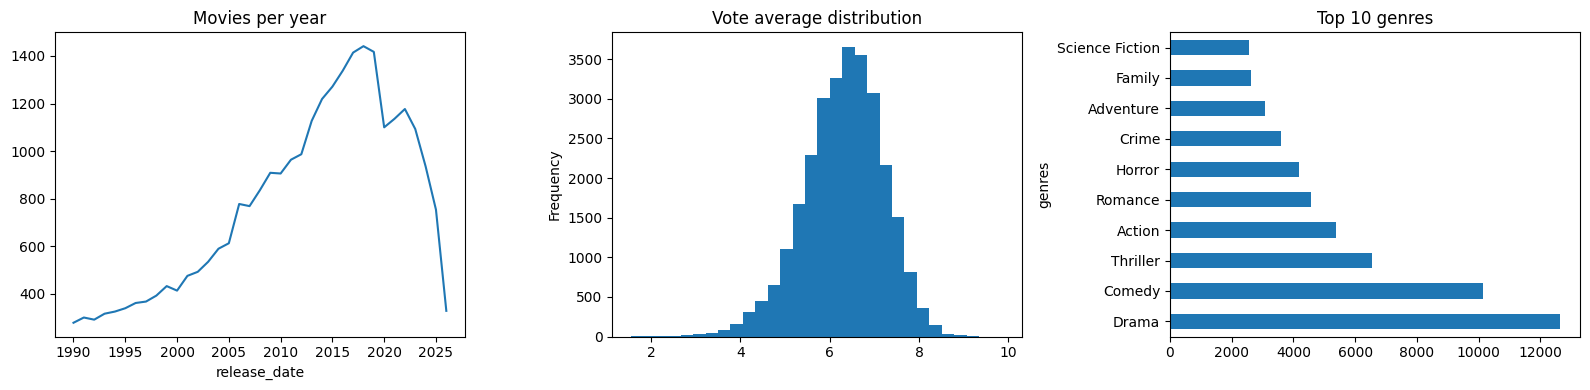

In [ ]:
# Cell 13 — A few quick sanity/exploration plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

movies["release_date"].dt.year.value_counts().sort_index().plot(ax=axes[0], title="Movies per year")
movies["vote_average"].dropna().plot(kind="hist", bins=30, ax=axes[1], title="Vote average distribution")
genre_names_per_movie.str.split(", ").explode().value_counts().head(10).plot(
    kind="barh", ax=axes[2], title="Top 10 genres"
)

plt.tight_layout()
plt.show()

# Data preparing and loading

#  1. Import Libraries

In [ ]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 2. Load ZIP Dataset

In [ ]:
ZIP_PATH = "/content/tables-20260926T175754Z-1-001.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall("/content/movie_data")

DATA_DIR = "/content/movie_data/tables"

files = os.listdir(DATA_DIR)
print("CSV files:")
for f in files:
    print("-", f)

CSV files:
- people.csv
- countries.csv
- keywords.csv
- movie_countries.csv
- movie_genres.csv
- genres.csv
- movie_crew.csv
- movie_production_companies.csv
- production_companies.csv
- movie_keywords.csv
- movie_cast.csv
- movies.csv


# 3. Load All Tables

In [ ]:
def load_csv(name):
    return pd.read_csv(os.path.join(DATA_DIR, name))

movies = load_csv("movies.csv")
countries = load_csv("countries.csv")
genres = load_csv("genres.csv")
keywords = load_csv("keywords.csv")
movie_countries = load_csv("movie_countries.csv")
production_companies = load_csv("production_companies.csv")
movie_genres = load_csv("movie_genres.csv")
movie_production_companies = load_csv("movie_production_companies.csv")
movie_keywords = load_csv("movie_keywords.csv")
people = load_csv("people.csv")
movie_cast = load_csv("movie_cast.csv")
movie_crew = load_csv("movie_crew.csv")


#  4. INITIAL EXPLORATION

In [ ]:
print("Movies shape:", movies.shape)
display(movies.head())
display(movies.info())
display(movies.describe(include="all").T)

Movies shape: (28433, 18)


,id,title,original_title,original_language,overview,release_date,popularity,vote_average,vote_count,adult,video,poster_path,backdrop_path,runtime,budget,revenue,status,tagline
0,5,Four Rooms,Four Rooms,en,It's Ted the Bellhop's first night on the job....,1995-12-09,7.5442,5.919,2909,False,False,/75aHn1NOYXh4M7L5shoeQ6NGykP.jpg,/c1BaOxC8bo5ACFYkYYxL0bBWRaq.jpg,98.0,4000000.0,4257354.0,Released,Twelve outrageous guests. Four scandalous requ...
1,6,Judgment Night,Judgment Night,en,"Four young friends, while taking a shortcut en...",1993-10-15,4.7176,6.446,389,False,False,/3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg,/lIuseocAIWrEq8zl4EBCBH96e4z.jpg,110.0,21000000.0,12136938.0,Released,Don't move. Don't whisper. Don't even breathe.
2,12,Finding Nemo,Finding Nemo,en,"Nemo, an adventurous young clownfish, is unexp...",2003-05-30,37.8341,7.822,21016,False,False,/eHuGQ10FUzK1mdOY69wF5pGgEf5.jpg,/eCynaAOgYYiw5yN5lBwz3IxqvaW.jpg,100.0,94000000.0,940335536.0,Released,There are 3.7 trillion fish in the ocean. They...
3,13,Forrest Gump,Forrest Gump,en,A man with a low IQ has accomplished great thi...,1994-06-23,39.4482,8.461,30525,False,False,/Cw4hIUIAmSYfK9QfaUW5igp9La.jpg,/66Kn4XWhkuPkJxOJyPEx4U2CUfN.jpg,142.0,55000000.0,677387716.0,Released,The world will never be the same once you've s...
4,14,American Beauty,American Beauty,en,"Lester Burnham, a depressed suburban father in...",1999-09-15,18.0452,7.997,13384,False,False,/wby9315QzVKdW9BonAefg8jGTTb.jpg,/2ndw55F40IkALzWyjCCza3M6nqM.jpg,122.0,15000000.0,356296601.0,Released,... look closer


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28433 entries, 0 to 28432
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 28433 non-null  int64  
 1   title              28433 non-null  object 
 2   original_title     28433 non-null  object 
 3   original_language  28433 non-null  object 
 4   overview           28373 non-null  object 
 5   release_date       28433 non-null  object 
 6   popularity         28433 non-null  float64
 7   vote_average       28433 non-null  float64
 8   vote_count         28433 non-null  int64  
 9   adult              28433 non-null  bool   
 10  video              28433 non-null  bool   
 11  poster_path        28425 non-null  object 
 12  backdrop_path      28285 non-null  object 
 13  runtime            28372 non-null  float64
 14  budget             10584 non-null  float64
 15  revenue            12237 non-null  float64
 16  status             284

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,28433.0,NaN,NaN,NaN,348972.366581,368885.278714,5.0,30634.0,252067.0,553456.0,1729723.0
title,28433,26910,Return,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_title,28433,27570,Return,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_language,28433,85,en,17593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overview,28373,28352,Miser Ebenezer Scrooge is awakened on Christma...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,28433,8853,2020-10-02,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,28433.0,NaN,NaN,NaN,4.885344,8.80888,0.0065,2.0939,3.0855,5.138,630.0457
vote_average,28433.0,NaN,NaN,NaN,6.310984,0.888941,1.555,5.764,6.37,6.924,9.9
vote_count,28433.0,NaN,NaN,NaN,800.092041,2222.99925,50.0,81.0,159.0,484.0,41265.0
adult,28433,1,False,28433,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#  5. Check Missing Values

In [ ]:
missing = movies.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values:")
display(missing.to_frame("missing_count"))

print("\nMissing percentage:")
display((missing / len(movies) * 100).round(2).to_frame("missing_percent"))

Missing values:


,missing_count
budget,17849
revenue,16196
tagline,10810
backdrop_path,148
runtime,61
overview,60
poster_path,8



Missing percentage:


,missing_percent
budget,62.78
revenue,56.96
tagline,38.02
backdrop_path,0.52
runtime,0.21
overview,0.21
poster_path,0.03


#  6. Check Duplicates

In [ ]:
print("Duplicate rows:", movies.duplicated().sum())

movies = movies.drop_duplicates().copy()

Duplicate rows: 0


#  7. DATA TYPES

In [ ]:
movies["release_date"] = pd.to_datetime(
    movies["release_date"], errors="coerce"
)

# 8. Date Feature Engineering

In [ ]:
movies["release_year"] = movies["release_date"].dt.year
movies["release_month"] = movies["release_date"].dt.month
movies["release_dayofweek"] = movies["release_date"].dt.dayofweek

movies.drop(columns=["release_date"], inplace=True)

# 9. Merge Genres

In [ ]:
genres = genres.rename(columns={"name": "genre_name"})

mg = movie_genres.merge(
    genres[["genre_id", "genre_name"]],
    on="genre_id",
    how="left"
)

genre_agg = (
    mg.groupby("movie_id")["genre_name"]
    .agg(lambda x: " | ".join(sorted(set(x.dropna()))))
    .rename("genres")
)

# 10. Merge Countries

In [ ]:
countries = countries.rename(columns={"name": "country_name"})

mc = movie_countries.merge(
    countries[["country_code", "country_name"]],
    on="country_code",
    how="left"
)

country_agg = (
    mc.groupby("movie_id")["country_name"]
    .agg(lambda x: " | ".join(sorted(set(x.dropna()))))
    .rename("countries")
)

# 11. Merge Production Companies

In [ ]:
production_companies = production_companies.rename(
    columns={"name": "company_name"}
)

mpc = movie_production_companies.merge(
    production_companies[["company_id", "company_name"]],
    on="company_id",
    how="left"
)

company_agg = (
    mpc.groupby("movie_id")["company_name"]
    .agg(lambda x: " | ".join(sorted(set(x.dropna()))))
    .rename("production_companies")
)


# 12. Merge Keywords

In [ ]:
keywords = keywords.rename(columns={"name": "keyword_name"})

mk = movie_keywords.merge(
    keywords[["keyword_id", "keyword_name"]],
    on="keyword_id",
    how="left"
)

keyword_agg = (
    mk.groupby("movie_id")["keyword_name"]
    .agg(lambda x: " | ".join(sorted(set(x.dropna()))))
    .rename("keywords")
)

# 13. Extract Directors

In [ ]:
people_names = people[["person_id", "name"]].rename(
    columns={"name": "person_name"}
)

crew_people = movie_crew.merge(
    people_names,
    on="person_id",
    how="left"
)

directors = crew_people[
    crew_people["job"].str.lower().eq("director")
]

director_agg = (
    directors.groupby("movie_id")["person_name"]
    .agg(lambda x: " | ".join(dict.fromkeys(x.dropna())))
    .rename("directors")
)

# 14. Create Relationship Features

In [ ]:
relationship_counts = pd.DataFrame({
    "cast_count":
        movie_cast.groupby("movie_id")["person_id"].nunique(),

    "crew_count":
        movie_crew.groupby("movie_id")["person_id"].nunique(),

    "unique_crew_departments":
        movie_crew.groupby("movie_id")["department"].nunique(),

    "keyword_count":
        movie_keywords.groupby("movie_id")["keyword_id"].nunique(),

    "genre_count":
        movie_genres.groupby("movie_id")["genre_id"].nunique(),

    "country_count":
        movie_countries.groupby("movie_id")["country_code"].nunique(),

    "production_company_count":
        movie_production_companies.groupby("movie_id")["company_id"].nunique()
})

#  15. BUILD MASTER TABLE

In [ ]:

master = movies.merge(
    genre_agg,
    left_on="id",
    right_index=True,
    how="left"
)

for table in [
    country_agg,
    company_agg,
    keyword_agg,
    director_agg,
    relationship_counts
]:
    master = master.merge(
        table,
        left_on="id",
        right_index=True,
        how="left"
    )

# Fill aggregated missing values
text_relation_cols = [
    "genres",
    "countries",
    "production_companies",
    "keywords",
    "directors"
]

for col in text_relation_cols:
    master[col] = master[col].fillna("Unknown")

for col in relationship_counts.columns:
    master[col] = master[col].fillna(0)

# 16. REMOVE CONSTANT / UNNECESSARY COLUMNS

In [ ]:

constant_cols = [
    col for col in master.columns
    if master[col].nunique(dropna=False) <= 1
]

print("Constant columns:", constant_cols)

master.drop(columns=constant_cols, inplace=True)

# Image paths are not useful for a normal tabular ML model.
for col in ["poster_path", "backdrop_path"]:
    if col in master.columns:
        master.drop(columns=col, inplace=True)


Constant columns: ['adult', 'video', 'status']


# 17. FINAL DATASET CHECK

In [ ]:
print("Final master shape:", master.shape)
display(master.head())

print("\nFinal missing values:")
display(
    master.isna().sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nDuplicate rows:", master.duplicated().sum())

Final master shape: (28433, 27)


,id,title,original_title,original_language,overview,popularity,vote_average,vote_count,runtime,budget,...,production_companies,keywords,directors,cast_count,crew_count,unique_crew_departments,keyword_count,genre_count,country_count,production_company_count
0,5,Four Rooms,Four Rooms,en,It's Ted the Bellhop's first night on the job....,7.5442,5.919,2909,98.0,4000000.0,...,A Band Apart | Miramax,anthology | bet | hoodlum | hotel | hotel room...,Allison Anders | Alexandre Rockwell | Robert R...,28.0,106.0,10.0,11.0,1.0,1.0,2.0
1,6,Judgment Night,Judgment Night,en,"Four young friends, while taking a shortcut en...",4.7176,6.446,389,110.0,21000000.0,...,JVC | Largo Entertainment,"boxing | chicago, illinois | drug dealer | esc...",Stephen Hopkins,31.0,17.0,9.0,5.0,4.0,2.0,2.0
2,12,Finding Nemo,Finding Nemo,en,"Nemo, an adventurous young clownfish, is unexp...",37.8341,7.822,21016,100.0,94000000.0,...,Pixar,3d animation | aftercreditsstinger | anthropom...,Andrew Stanton,69.0,360.0,9.0,23.0,3.0,1.0,1.0
3,13,Forrest Gump,Forrest Gump,en,A man with a low IQ has accomplished great thi...,39.4482,8.461,30525,142.0,55000000.0,...,Paramount Pictures | The Steve Tisch Company |...,1960s | 1970s | alabama | america | anti war p...,Robert Zemeckis,145.0,171.0,11.0,32.0,3.0,1.0,3.0
4,14,American Beauty,American Beauty,en,"Lester Burnham, a depressed suburban father in...",18.0452,7.997,13384,122.0,15000000.0,...,DreamWorks Pictures | Jinks/Cohen Company,adultery | age difference | camcorder | cheati...,Sam Mendes,41.0,147.0,11.0,36.0,1.0,1.0,2.0



Final missing values:


,0
budget,17849
revenue,16196
tagline,10810
runtime,61
overview,60
id,0
original_title,0
vote_average,0
popularity,0
original_language,0



Duplicate rows: 0


# 18. NUMERICAL FEATURES

In [ ]:

numerical_cols = master.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

Numerical columns:
['id', 'popularity', 'vote_average', 'vote_count', 'runtime', 'budget', 'revenue', 'release_year', 'release_month', 'release_dayofweek', 'cast_count', 'crew_count', 'unique_crew_departments', 'keyword_count', 'genre_count', 'country_count', 'production_company_count']


# 19. CATEGORICAL FEATURES

In [ ]:

categorical_cols = master.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['title', 'original_title', 'original_language', 'overview', 'tagline', 'genres', 'countries', 'production_companies', 'keywords', 'directors']


# 20. OUTLIER CHECK WITH IQR

In [ ]:

outlier_summary = []

for col in numerical_cols:
    Q1 = master[col].quantile(0.25)
    Q3 = master[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((master[col] < lower) | (master[col] > upper)).sum()

    outlier_summary.append({
        "column": col,
        "outliers": count,
        "percentage": round(count / len(master) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary.sort_values("outliers", ascending=False))

,column,outliers,percentage
3,vote_count,4142,14.57
1,popularity,2652,9.33
11,crew_count,2510,8.83
4,runtime,2155,7.58
6,revenue,1629,5.73
10,cast_count,1539,5.41
16,production_company_count,1400,4.92
5,budget,1075,3.78
14,genre_count,1010,3.55
15,country_count,978,3.44


# 21. SKEWNESS

,skewness
popularity,29.450446
vote_count,6.785614
revenue,6.371329
crew_count,3.941543
budget,3.525540
cast_count,3.103241
country_count,2.919080
production_company_count,2.088173
keyword_count,1.659064
runtime,1.396443


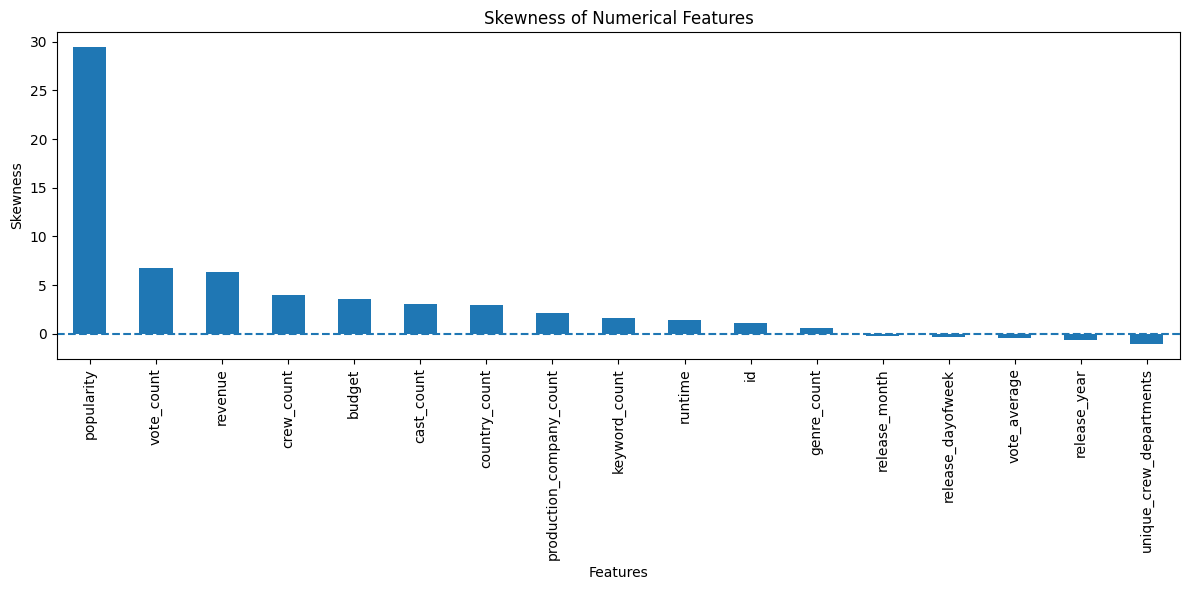

In [ ]:
import matplotlib.pyplot as plt

skewness = (
    master[numerical_cols]
    .skew()
    .sort_values(ascending=False)
)

# Display skewness values
display(skewness.to_frame("skewness"))

# Plot skewness
plt.figure(figsize=(12, 6))
skewness.plot(kind="bar")

plt.axhline(y=0, linestyle="--")
plt.title("Skewness of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Skewness")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 22. VISUALIZATION

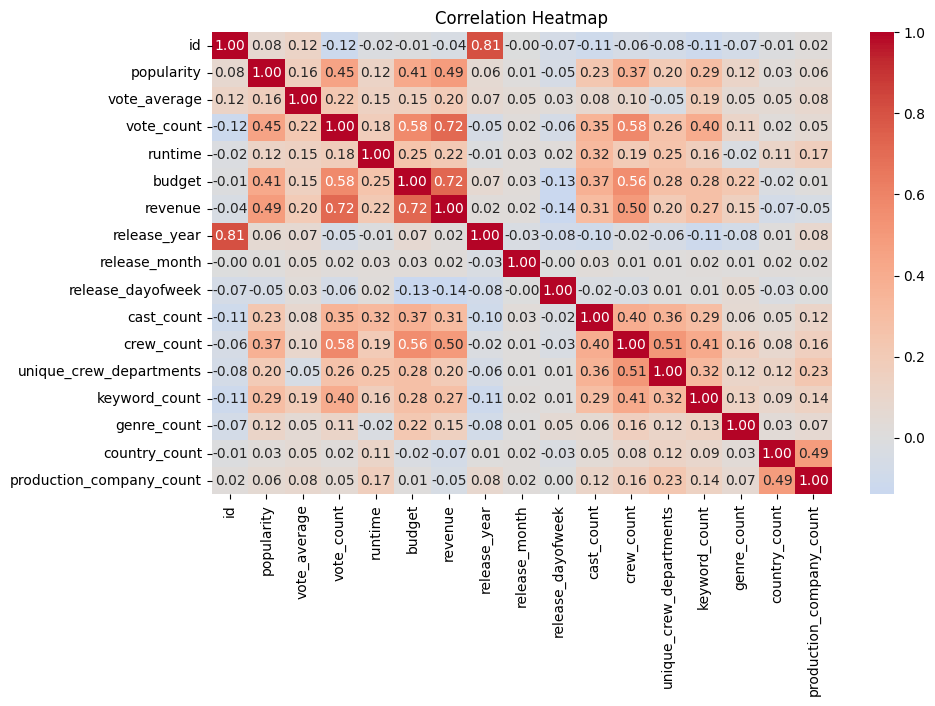

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    master[numerical_cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,      # Display correlation values
    fmt=".2f"        # Show 2 decimal places
)

plt.title("Correlation Heatmap")
plt.show()

# 25. SAVE MASTER DATASET

In [ ]:
master.to_csv(
    "/content/movies_master_preprocessed.csv",
    index=False
)

print("Saved: movies_master_preprocessed.csv")


Saved: movies_master_preprocessed.csv


# Hybrid Movie Recommendation System

A simple content-based recommender using **TF-IDF + Cosine Similarity**. It builds a user profile from movies they like and recommends the 20 most similar movies.

Place `movies_cleaned.csv` in the same folder as this notebook before running it.

## 1. Install dependencies (run once if needed)

In [ ]:
%pip install -q pandas scikit-learn scipy

## 2. Import libraries and load the dataset

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

CSV_PATH = "movies_cleaned.csv"
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

## 3. Detect the relevant columns

In [ ]:
column_aliases = {
    "title": ["title", "movie_title", "name", "original_title"],
    "description": ["description", "overview", "plot", "storyline", "summary"],
    "genres": ["genres", "genre"],
    "director": ["director", "directors"],
    "cast": ["cast", "actors", "stars", "starring"],
    "keywords": ["keywords", "tags"]
}

column_lookup = {col.lower().strip(): col for col in df.columns}
columns = {}

for feature, aliases in column_aliases.items():
    for alias in aliases:
        if alias in column_lookup:
            columns[feature] = column_lookup[alias]
            break

if "title" not in columns:
    raise ValueError("Could not find the movie title column. Please update column_aliases.")

if not any(feature in columns for feature in ["description", "genres", "director", "cast", "keywords"]):
    raise ValueError("No movie feature columns found. Check your CSV column names.")

print("Detected columns:", columns)

## 4. Clean the data

In [ ]:
df = df.dropna(subset=[columns["title"]]).copy()

feature_names = ["description", "genres", "director", "cast", "keywords"]
for feature in feature_names:
    if feature in columns:
        col = columns[feature]
        df[col] = df[col].fillna("").astype(str)

df = df.drop_duplicates(subset=[columns["title"]], keep="first").reset_index(drop=True)
df[columns["title"]] = df[columns["title"]].astype(str)

print("Dataset after cleaning:", df.shape)

## 5. Combine movie features

Genres, director, cast, and keywords are repeated to give them more influence than the description. These are starting weights and can be adjusted.

In [ ]:
def build_movie_text(row):
    parts = []
    feature_weights = {
        "description": 1,
        "genres": 3,
        "director": 2,
        "cast": 2,
        "keywords": 2
    }

    for feature, weight in feature_weights.items():
        if feature in columns:
            value = str(row[columns[feature]]).strip()
            if value and value.lower() != "nan":
                parts.extend([value] * weight)

    return " ".join(parts)

df["combined_features"] = df.apply(build_movie_text, axis=1)
df = df[df["combined_features"].str.strip().ne("")].reset_index(drop=True)

display(df[[columns["title"], "combined_features"]].head())

## 6. Create TF-IDF vectors

In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df["combined_features"])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

## 7. Find movies by title

In [ ]:
def find_movie_indices(movie_title):
    title_col = columns["title"]
    matches = df[
        df[title_col].str.casefold() == movie_title.strip().casefold()
    ]

    if matches.empty:
        matches = df[
            df[title_col].str.contains(
                movie_title.strip(), case=False, regex=False, na=False
            )
        ]

    return matches.index.tolist()

# Example:
# find_movie_indices("Interstellar")

## 8. Build a user profile

The profile is the average TF-IDF vector of the movies the user likes.

In [ ]:
def build_user_profile(liked_movies):
    movie_indices = []
    not_found = []

    for title in liked_movies:
        matches = find_movie_indices(title)
        if matches:
            movie_indices.append(matches[0])
        else:
            not_found.append(title)

    if not movie_indices:
        raise ValueError("None of the selected movies were found in the dataset.")

    user_profile = np.asarray(tfidf_matrix[movie_indices].mean(axis=0))
    return user_profile, movie_indices, not_found

## 9. Recommendation function

In [ ]:
def recommend_for_user(liked_movies, top_n=20):
    user_profile, liked_indices, not_found = build_user_profile(liked_movies)

    scores = cosine_similarity(user_profile, tfidf_matrix).flatten()
    scores[liked_indices] = -1  # Exclude movies the user already likes

    ranked_indices = np.argsort(scores)[::-1]
    ranked_indices = [idx for idx in ranked_indices if scores[idx] > 0][:top_n]

    result = df.iloc[ranked_indices].copy()
    result["similarity"] = scores[ranked_indices]

    output_cols = [columns["title"]]
    for feature in ["genres", "director"]:
        if feature in columns:
            output_cols.append(columns[feature])
    output_cols.append("similarity")

    if not_found:
        print("Movies not found:", not_found)

    return result[output_cols].reset_index(drop=True)

## 10. Test the recommender

Edit `liked_movies` to reflect the user's preferences. Titles must exist in the CSV.

In [ ]:
liked_movies = [
    "Interstellar",
    "Inception",
    "The Martian"
]

recommendations = recommend_for_user(liked_movies, top_n=20)

print("Movies liked by the user:")
for movie in liked_movies:
    print("-", movie)

print("\nTop recommendations:")
display(recommendations)

recommendations.to_csv("user_recommendations.csv", index=False)
print("Saved to user_recommendations.csv")

----------------------------------------------------------------------------------------------------------

Chatbot - Intent Detection

In [ ]:
def detect_intent(user_input):
    text = user_input.lower().strip()

    # Similar movies
    if any(word in text for word in [
        "similar",
        "like",
        "recommend",
        "recommendation",
        "suggest"
    ]):
        return "similar_movies"

    # Movie information
    if any(word in text for word in [
        "about",
        "story",
        "plot",
        "what is"
    ]):
        return "movie_info"

    return "unknown"

In [ ]:
# Test Intent Detection

test_questions = [
    "I want movies similar to Interstellar",
    "Can you recommend a movie like Inception?",
    "Tell me about Interstellar",
    "What is the story of Inception?",
    "Hello"
]

for question in test_questions:
    print("Question:", question)
    print("Intent:", detect_intent(question))
    print("-" * 50)

Question: I want movies similar to Interstellar
Intent: similar_movies
--------------------------------------------------
Question: Can you recommend a movie like Inception?
Intent: similar_movies
--------------------------------------------------
Question: Tell me about Interstellar
Intent: movie_info
--------------------------------------------------
Question: What is the story of Inception?
Intent: movie_info
--------------------------------------------------
Question: Hello
Intent: unknown
--------------------------------------------------


In [ ]:
# 12. Extract Movie Title

def extract_movie_title(user_input):
    text = user_input.strip().lower()

    # Get all movie titles from the dataset
    movie_titles = df[columns["title"]].dropna().astype(str).tolist()

    # Sort by length so longer titles are checked first
    movie_titles = sorted(movie_titles, key=len, reverse=True)

    for title in movie_titles:
        title_clean = title.strip().lower()

        # Ignore very short titles
        if len(title_clean) < 3:
            continue

        # Check if the complete title appears in the user's question
        if title_clean in text:
            return title

    return None
#test
test_questions = [
    "I want movies similar to Interstellar",
    "Can you recommend a movie like Inception?",
    "Tell me about The Martian",
    "What is the story of Finding Nemo?"
]

for question in test_questions:
    movie = extract_movie_title(question)

    print("Question:", question)
    print("Movie:", movie)
    print("-" * 50)

Question: I want movies similar to Interstellar
Movie: Interstellar
--------------------------------------------------
Question: Can you recommend a movie like Inception?
Movie: Inception
--------------------------------------------------
Question: Tell me about The Martian
Movie: The Martian
--------------------------------------------------
Question: What is the story of Finding Nemo?
Movie: Finding Nemo
--------------------------------------------------


# Connect Chatbot with Recommendation System

In [ ]:
def process_user_question(user_input, top_n=10):

    intent = detect_intent(user_input)

    movie_title = extract_movie_title(user_input)

    print("Intent:", intent)
    print("Movie:", movie_title)

    # Similar movies
    if intent == "similar_movies":

        if movie_title is None:
            return "I couldn't find a movie title in your question."

        recommendations = recommend_for_user(
            [movie_title],
            top_n=top_n
        )

        return format_recommendations(
            recommendations,
            movie_title
        )

    # Movie information
    elif intent == "movie_info":

        if movie_title is None:
            return "I couldn't find a movie title in your question."

        movie_info = get_movie_info(movie_title)

        if movie_info is None:
            return f"I couldn't find information about {movie_title}."

        return format_movie_info(movie_info)

    # Unknown
    else:

        return (
            "Hi! I can help you discover movies.\n\n"
            "Try asking:\n"
            "- Movies similar to Interstellar\n"
            "- Recommend movies like Inception\n"
            "- Tell me about Interstellar"
        )

#  Get Movie Information

In [ ]:
def get_movie_info(movie_title):
    title_col = columns["title"]

    matches = df[
        df[title_col].str.casefold() == movie_title.strip().casefold()
    ]

    if matches.empty:
        return None

    movie = matches.iloc[0]

    info = {
        "title": movie.get(title_col, ""),
        "overview": movie.get(columns.get("description", ""), ""),
        "release_date": movie.get("release_date", ""),
        "rating": movie.get("vote_average", ""),
        "vote_count": movie.get("vote_count", ""),
        "runtime": movie.get("runtime", ""),
        "popularity": movie.get("popularity", ""),
    }

    return info

In [ ]:
def format_movie_info(movie_info):

    if movie_info is None:
        return "Sorry, I couldn't find this movie in the dataset."

    response = f"""
Movie: {movie_info['title']}

Overview:
{movie_info['overview']}

Release Date: {movie_info['release_date']}
Rating: {movie_info['rating']}
Vote Count: {movie_info['vote_count']}
Runtime: {movie_info['runtime']} minutes
Popularity: {movie_info['popularity']}
"""

    return response
info = get_movie_info("Interstellar")

print(format_movie_info(info))


Movie: Interstellar

Overview:
The adventures of a group of explorers who make use of a newly discovered wormhole to surpass the limitations on human space travel and conquer the vast distances involved in an interstellar voyage.

Release Date: 2014-11-05
Rating: 8.488
Vote Count: 41265
Runtime: 169 minutes
Popularity: 70.8399



In [ ]:
test_questions = [
    "I want movies similar to Interstellar",
    "Recommend movies like Inception",
    "Give me movies similar to The Martian",
    "Tell me about Interstellar",
    "What is the story of Inception?",
    "What is Interstellar about?",
    "Hello"
]

for question in test_questions:

    print("=" * 70)
    print("Question:", question)

    result = process_user_question(question, top_n=5)

    print("\nResponse:")

    if isinstance(result, pd.DataFrame):
        display(result)
    else:
        print(result)

Question: I want movies similar to Interstellar
Intent: similar_movies
Movie: Interstellar

Response:
Movies similar to Interstellar:

1. Midnight Special (similarity: 0.556)

Question: Recommend movies like Inception
Intent: similar_movies
Movie: Inception

Response:
Movies similar to Inception:

1. Babylon 5: The River of Souls (similarity: 0.518)

Question: Give me movies similar to The Martian
Intent: similar_movies
Movie: The Martian

Response:
Movies similar to The Martian:

1. Spaceman (similarity: 0.507)

Question: Tell me about Interstellar
Intent: movie_info
Movie: Interstellar

Response:

Movie: Interstellar

Overview:
The adventures of a group of explorers who make use of a newly discovered wormhole to surpass the limitations on human space travel and conquer the vast distances involved in an interstellar voyage.

Release Date: 2014-11-05
Rating: 8.488
Vote Count: 41265
Runtime: 169 minutes
Popularity: 70.8399

Question: What is the story of Inception?
Intent: movie_info
Mo

In [ ]:
def format_recommendations(recommendations, movie_title):

    if recommendations.empty:
        return f"I couldn't find recommendations for {movie_title}."

    response = f"Movies similar to {movie_title}:\n\n"

    for i, row in recommendations.iterrows():

        title = row[columns["title"]]
        similarity = row["similarity"]

        response += (
            f"{i + 1}. {title} "
            f"(similarity: {similarity:.3f})\n"
        )

        return response
questions = [
  "I want movies similar to Interstellar",
  "Tell me about Interstellar",
  "Hello"
]

for question in questions:

    print("=" * 70)
    print("USER:", question)
    print()

    response = process_user_question(question)

    print("BOT:")
    print(response)

USER: I want movies similar to Interstellar

Intent: similar_movies
Movie: Interstellar
BOT:
Movies similar to Interstellar:

1. Midnight Special (similarity: 0.556)

USER: Tell me about Interstellar

Intent: movie_info
Movie: Interstellar
BOT:

Movie: Interstellar

Overview:
The adventures of a group of explorers who make use of a newly discovered wormhole to surpass the limitations on human space travel and conquer the vast distances involved in an interstellar voyage.

Release Date: 2014-11-05
Rating: 8.488
Vote Count: 41265
Runtime: 169 minutes
Popularity: 70.8399

USER: Hello

Intent: unknown
Movie: Hello
BOT:
Hi! I can help you discover movies.

Try asking:
- Movies similar to Interstellar
- Recommend movies like Inception
- Tell me about Interstellar


# streamlit

In [ ]:
!pip install -q streamlit

In [ ]:
import streamlit as st

print("Streamlit version:", st.__version__)

Streamlit version: 1.64.0


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'app.py', 'movies_cleaned (1)-1.csv', 'streamlit.log', 'movies_cleaned (1).csv', '.ipynb_checkpoints', 'user_recommendations.csv', 'sample_data']


In [ ]:
%%writefile /content/app.py

import streamlit as st
import pandas as pd

# Load dataset
df = pd.read_csv("/content/movies_cleaned (1).csv")

st.title("🎬 Movie Chatbot")

st.write("Dataset loaded successfully!")

st.write("Number of movies:", len(df))

st.dataframe(df.head())

Overwriting /content/app.py


In [ ]:
!streamlit run /content/app.py &>/content/streamlit.log &

In [ ]:
!cat /content/streamlit.log

In [ ]:
!pip install -q pyngrok

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3JUoN3xQkU6Ow3btBZwqlaJi8AJ_5ct7VpfPybduyczxop4H9")

print("Token configured successfully")

Token configured successfully


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://video-excavate-blooper.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile /content/app.py

import streamlit as st

st.set_page_config(
    page_title="Movie Chatbot",
    page_icon="🎬"
)

st.title("🎬 Movie Chatbot")

st.write("Ask me anything about movies!")

user_input = st.chat_input("Type your question here...")

if user_input:
    st.chat_message("user").write(user_input)

    with st.chat_message("assistant"):
        st.write("🤖 I received your message!")

Overwriting /content/app.py


In [ ]:
!pkill -f "streamlit run" || true

^C


In [ ]:
!streamlit run /content/app.py &>/content/streamlit.log &

In [ ]:
%%writefile /content/app.py

Overwriting /content/app.py


In [ ]:
!pkill -f "streamlit run" || true

^C


In [ ]:
!streamlit run /content/app.py &>/content/streamlit.log &

In [ ]:
from pyngrok import ngrok

tunnels = ngrok.get_tunnels()

for tunnel in tunnels:
    print(tunnel.public_url)

https://video-excavate-blooper.ngrok-free.dev


In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded successfully ✅")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully ✅


In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# Load dataset
df = pd.read_csv("/content/movies_cleaned (1)-1.csv")

# Fill missing values
df["overview"] = df["overview"].fillna("").astype(str)
df["genres"] = df["genres"].fillna("").astype(str)

# Create text for embedding
df["embedding_text"] = (
    df["overview"]
    + " Genres: "
    + df["genres"]
)

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Create embeddings
embeddings = model.encode(
    df["embedding_text"].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/889 [00:00<?, ?it/s]

Embeddings shape: (28433, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def semantic_recommend(movie_title, top_n=10):

    # Find movie
    matches = df[
        df["title"].str.casefold()
        == movie_title.strip().casefold()
    ]

    if matches.empty:
        return pd.DataFrame()

    movie_index = matches.index[0]

    # Similarity between selected movie and all movies
    scores = cosine_similarity(
        embeddings[movie_index].reshape(1, -1),
        embeddings
    ).flatten()

    # Don't recommend the same movie
    scores[movie_index] = -1

    # Get highest similarities
    ranked_indices = np.argsort(scores)[::-1][:top_n]

    result = df.iloc[ranked_indices].copy()

    result["similarity"] = scores[ranked_indices]

    return result[
        [
            "title",
            "genres",
            "vote_average",
            "release_year",
            "similarity"
        ]
    ].reset_index(drop=True)

In [ ]:
recommendations = semantic_recommend(
    "Interstellar",
    top_n=10
)

display(recommendations)

,title,genres,vote_average,release_year,similarity
0,Prometheus,Horror | Mystery | Science Fiction,6.610,2012,0.705774
1,Space Chimps,Adventure | Animation | Comedy | Family | Scie...,4.900,2008,0.667493
2,The Beyond,Science Fiction,5.493,2018,0.647750
3,Voyagers,Science Fiction | Thriller,5.962,2021,0.618965
4,Star Trek Beyond,Action | Adventure | Science Fiction,6.800,2016,0.609680
5,Project Gemini,Science Fiction | Thriller,5.655,2022,0.604707
6,Strange World,Adventure | Animation | Family | Fantasy | Sci...,6.200,2022,0.591184
7,Europa Report,Drama | Science Fiction | Thriller,6.301,2013,0.587642
8,Passengers,Drama | Romance | Science Fiction,6.955,2016,0.583165
9,Books of Blood,Horror | Science Fiction,6.274,2020,0.581581


In [ ]:
import numpy as np

np.save(
    "/content/movie_embeddings.npy",
    embeddings
)

print("Embeddings saved successfully ✅")

Embeddings saved successfully ✅


In [ ]:
import os

# Rename dataset
os.rename(
    "/content/movies_cleaned (1).csv",
    "/content/movies_cleaned.csv"
)

# Fix paths inside app.py
path = "/content/app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

code = code.replace(
    '"/content/movies_cleaned (1).csv"',
    '"movies_cleaned.csv"'
)

code = code.replace(
    '"/content/movie_embeddings.npy"',
    '"movie_embeddings.npy"'
)

with open(path, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Files prepared for deployment")

✅ Files prepared for deployment


In [ ]:
import os

for file in [
    "/content/app.py",
    "/content/movies_cleaned.csv",
    "/content/movie_embeddings.npy"
]:
    size = os.path.getsize(file) / (1024 * 1024)
    print(f"{os.path.basename(file)} → {size:.2f} MB")

app.py → 0.02 MB
movies_cleaned.csv → 17.28 MB
movie_embeddings.npy → 41.65 MB


In [ ]:
import numpy as np
import os

# Load current embeddings
embeddings = np.load("/content/movie_embeddings.npy")

print("Before:", embeddings.shape)
print("Before size:", os.path.getsize("/content/movie_embeddings.npy") / (1024 * 1024), "MB")

# Convert float32 → float16
embeddings_small = embeddings.astype(np.float16)

# Save the smaller version
np.save("/content/movie_embeddings.npy", embeddings_small)

print("After:", embeddings_small.shape)
print("After size:", os.path.getsize("/content/movie_embeddings.npy") / (1024 * 1024), "MB")

Before: (28433, 384)
Before size: 41.6500244140625 MB
After: (28433, 384)
After size: 20.8250732421875 MB


In [ ]:
import numpy as np

path = "/content/movie_embeddings.npy"

embeddings = np.load(path, allow_pickle=False)

print("Shape:", embeddings.shape)
print("Dtype:", embeddings.dtype)
print("Type:", type(embeddings))

Shape: (28433, 384)
Dtype: float16
Type: <class 'numpy.ndarray'>


In [ ]:
import numpy as np

embeddings = np.load("/content/movie_embeddings.npy", allow_pickle=False)

# تأكد أنها float16
embeddings = embeddings.astype(np.float16)

# احفظ نسخة جديدة باسم مختلف مؤقتًا
np.save("/content/movie_embeddings_deploy.npy", embeddings)

# تأكد من النسخة الجديدة
test = np.load("/content/movie_embeddings_deploy.npy", allow_pickle=False)

print("Shape:", test.shape)
print("Dtype:", test.dtype)
print("Size:", test.nbytes / (1024 * 1024), "MB")

Shape: (28433, 384)
Dtype: float16
Size: 20.824951171875 MB


In [ ]:
from google.colab import files

files.download("/content/movie_embeddings_deploy.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>